# Day 7 | Lab 7.4 (PROJECT 1): Financial Analyst Agentic RAG Agent
## ReAct Agent + Vector RAG + SQL Database + Live Web Search

**Duration:** ~1.5 hours · **Type:** Applied capstone

**Scenario.** **Meridian Wealth Partners** manages ₹2,000 Cr in assets for 800 high-net-worth clients across India. Financial analysts spend 3-5 hours preparing for each quarterly client meeting — pulling portfolio data from internal databases, checking live market conditions, running performance calculations, searching investment policy PDFs, and browsing the web for sector news. We build a **production-grade ReAct agent** that automates this workflow end-to-end. *(Scenario preserved verbatim from the source notebook.)*

**Learning Objectives.** By the end of this lab, you will be able to:
1. Build a **ReAct agent** with `from langchain.agents import create_agent` (LangChain v1) that selects from 4+ heterogeneous tools per query.
2. Wire a **SQL tool** so the agent can query a portfolio/transactions database via natural language.
3. Wire a **vector RAG tool** over policy PDFs so the agent can cite investment policy clauses.
4. Wire a **live web-search tool** (Tavily) so the agent can pull current market news.
5. Trace agent reasoning end-to-end and debug tool selection / tool failures.

**Tools.** LangChain v1 (`create_agent`) · LangGraph v1 · `langchain-openai` · `langchain-community` (FAISS, PyPDF) · `langchain-tavily` · `gpt-4.1-mini`.

*Created by Prashant Sahu · [LinkedIn](https://www.linkedin.com/in/prashantksahu/)*

---


## 1. Install Dependencies

In [ ]:
# Required packages for this lab — already installed in your local venv.
# To install standalone, uncomment the line(s) below:
# !pip install -q 'langchain>=1.0' 'langchain-core>=1.0' 'langchain-openai>=1.0' 'langchain-community>=0.3' 'langgraph>=1.0' 'langchain-tavily>=0.1' faiss-cpu pypdf langchain-text-splitters tavily-python


## 2. API Key Configuration

> **Setup:** Go to the 🔑 icon in Colab's left sidebar → Add `OPENAI_API_KEY` and `TAVILY_API_KEY` → Toggle "Notebook access" ON.
>
> **Tavily API Key:** Sign up free at [tavily.com](https://tavily.com) → Dashboard → Copy API key. Free tier includes 1,000 searches/month.

In [1]:
import os

# Local-venv pattern: load from .env if python-dotenv is available, otherwise rely on
# environment variables already set in your shell or venv activation script.
try:
    from dotenv import load_dotenv
    load_dotenv("..\\.env")
except ImportError:
    pass

for key in ['OPENAI_API_KEY', 'TAVILY_API_KEY']:
    status = '✅ Loaded' if os.environ.get(key) else '❌ MISSING'
    print(f'{key}: {status}')


OPENAI_API_KEY: ✅ Loaded
TAVILY_API_KEY: ✅ Loaded


## 3. Initialize Clients & Imports

In [2]:
from openai import OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.tools import tool
# from langgraph.prebuilt import create_react_agent  # langchain 0.3.3
from langchain.agents import create_agent  # as per langchain v1.01
from langchain_tavily import TavilySearch

client = OpenAI()
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
llm = ChatOpenAI(model="gpt-5-mini")

print("All clients initialized ✅")
print(f"  Agent LLM: gpt-5-mini (via ChatOpenAI)")
print(f"  Embeddings: text-embedding-3-small")
print(f"  Web Search: Tavily API")

All clients initialized ✅
  Agent LLM: gpt-5-mini (via ChatOpenAI)
  Embeddings: text-embedding-3-small
  Web Search: Tavily API


## 4. Agent Architecture

```
                         ┌──────────────────────┐
                         │   User Query         │
                         │ "Prepare briefing    │
                         │  for Client CLT-001" │
                         └──────────┬───────────┘
                                    │
                                    ▼
                    ┌───────────────────────────────┐
                    │       ReAct Agent (LLM)       │
                    │   gpt-5-mini via LangGraph    │
                    │                               │
                    │  Loop: Thought → Action →     │
                    │        Observation → ...      │
                    └──────┬──┬──┬──┬──┬────────────┘
                           │  │  │  │  │
              ┌────────────┘  │  │  │  └────────────┐
              ▼               ▼  │  ▼               ▼
    ┌──────────────┐ ┌────────┐  │ ┌──────────┐ ┌──────────┐
    │ portfolio_   │ │market_ │  │ │ policy_  │ │  web_    │
    │ lookup       │ │data_   │  │ │retriever │ │ search   │
    │              │ │search  │  │ │ (RAG)    │ │(Tavily)  │
    │ Client DB    │ │Ticker  │  │ │ FAISS +  │ │ Live web │
    │ Holdings     │ │Data    │  │ │ Policies │ │ results  │
    └──────────────┘ └────────┘  │ └──────────┘ └──────────┘
                                 ▼
                        ┌──────────────┐
                        │ calculate_   │
                        │ metrics      │
                        │ Returns,     │
                        │ allocations  │
                        └──────────────┘
```

**Data architecture mirrors real enterprise systems:**
- **Structured data** (portfolios, market prices) → SQL database (SQLite)
- **Unstructured data** (policy documents) → PDF files → chunked → embedded → FAISS vector store
- **Real-time data** (news, market updates) → Tavily web search API

## About the ReAct Agent:

The ReAct agent we are building is best described as a **LangChain agent that runs on LangGraph**: we'll create it through LangChain’s high-level `create_agent` API, but under the hood that API builds a **graph-based runtime using LangGraph**, where the execution loop is modeled as nodes and edges such as the model node, tools node, and stop/final-output path.

In other words, **LangChain is the developer-facing abstraction**, while **LangGraph is the orchestration/runtime layer** actually managing the ReAct loop, tool execution, middleware, streaming, persistence, and related agent control flow.

You use LangChain because it gives you the simpler, faster, more ergonomic entry point for common agent patterns, provider integrations, tools, and middleware, whereas you drop down to LangGraph only when you need lower-level control over custom orchestration, state transitions, durable execution, or nonstandard agent workflows. ([LangChain Docs][1])

[1]: https://docs.langchain.com/oss/python/langchain/agents?utm_source=chatgpt.com "Agents - Docs by LangChain"


In [7]:
# !unzip policy_documents.zip -d .
!tar -xf policy_documents.zip

## 5. Connect to the SQLite Database

In [8]:
DB_PATH = "meridian_wealth.db"

# Verify database exists and has data
assert os.path.exists(DB_PATH), f"❌ Database not found at {DB_PATH}. Run Lab_04_Data_Setup.ipynb first!"

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print(f"✅ Connected to database: {DB_PATH}")
print(f"   File size: {os.path.getsize(DB_PATH) / 1024:.1f} KB\n")

for table in ["clients", "holdings", "market_data"]:
    count = cursor.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"   📋 {table}: {count} rows")

# Preview clients
print("\n👤 Clients:")
for row in cursor.execute("SELECT client_id, name, risk_profile, aum_inr FROM clients"):
    print(f"   {row[0]}: {row[1]} | {row[2]} | AUM: ₹{row[3]:,.0f}")

conn.close()

NameError: name 'sqlite3' is not defined

## 6. Load Policy PDFs → Split → Embed → FAISS Vector Store

This is the production RAG pipeline. We load 5 real PDF policy documents through LangChain's document processing chain:

1. **`PyPDFLoader`** — extracts text from each PDF page (preserving page metadata)
2. **`RecursiveCharacterTextSplitter`** — breaks text into overlapping chunks (500 chars, 100 overlap)
3. **`OpenAIEmbeddings`** — converts each chunk to a 1536-dimensional vector
4. **`FAISS`** — indexes vectors for fast similarity search at query time

This is exactly how enterprise RAG systems work with corporate document repositories.

In [9]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

POLICY_DIR = "policy_documents"
assert os.path.exists(POLICY_DIR), f"❌ Policy documents not found at {POLICY_DIR}/. Upload the policy_documents folder!"

# Step 1: Load all PDFs using LangChain's PyPDFLoader
all_pages = []
pdf_files = sorted([f for f in os.listdir(POLICY_DIR) if f.endswith(".pdf")])

print(f"📄 Loading {len(pdf_files)} policy PDFs...\n")
for pdf_file in pdf_files:
    loader = PyPDFLoader(os.path.join(POLICY_DIR, pdf_file))
    pages = loader.load()
    all_pages.extend(pages)
    print(f"   {pdf_file}: {len(pages)} pages loaded")

print(f"\n✅ Total pages extracted: {len(all_pages)}")

📄 Loading 5 policy PDFs...

   Asset_Allocation_Policy.pdf: 20 pages loaded
   Client_Suitability_Standards.pdf: 71 pages loaded
   Quarterly_Reporting_Standards.pdf: 33 pages loaded
   Rebalancing_Protocol.pdf: 20 pages loaded
   Risk_Management_Guidelines.pdf: 30 pages loaded

✅ Total pages extracted: 174


In [10]:
type(all_pages[0])

langchain_core.documents.base.Document

In [23]:
# Step 2: Split into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,         # ~125 words per chunk — good for policy docs
    chunk_overlap=300,       # 100 char overlap prevents losing context at chunk boundaries
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]  # split on paragraphs first, then sentences
)

chunks = text_splitter.split_documents(all_pages)
print(f"✅ Split into {len(chunks)} chunks (chunk_size=500, overlap=100)")


✅ Split into 713 chunks (chunk_size=500, overlap=100)


In [24]:
# Preview a few chunks
print(f"\n📋 Sample Chunks:")
for i in [0, len(chunks)//3, 2*len(chunks)//3]:
    c = chunks[i]
    src = os.path.basename(c.metadata.get("source", "?"))
    pg = c.metadata.get("page", "?")
    print(f"\n  Chunk [{i}] from {src} (page {pg}):")
    print(f"  \"{c.page_content[:120]}...\"")



📋 Sample Chunks:

  Chunk [0] from Asset_Allocation_Policy.pdf (page 0):
  "MERIDIAN WEALTH PARTNERS
 ASSET ALLOCATION POLICY
 Investment Advisory Firm | SEBI Registration: INA000015429
 Effective..."

  Chunk [237] from Client_Suitability_Standards.pdf (page 39):
  "client advisory relationships must carefully review and completely understand the requirements specified
herein and ensu..."

  Chunk [475] from Quarterly_Reporting_Standards.pdf (page 18):
  "MERIDIAN WEALTH PARTNERS — CONFIDENTIAL
For Internal Use Only | Effective: January 2026
Page 19
further notes that inves..."


In [31]:
print(chunks[1].metadata["page"], "\n",  chunks[1].page_content)

1 
 TABLE OF CONTENTS
1. Document Control
2. Purpose, Scope & Applicability
3. Regulatory Framework & Compliance
4. Definitions & Interpretation
5. Investment Philosophy & Guiding Principles
6. Strategic Asset Allocation Framework
7. Tactical Asset Allocation
8. Concentration Limits & Diversification
9. Market Capitalization Classification
10. Prohibited & Restricted Investments
11. Alternative Investments Framework
12. Cash & Liquidity Management
13. Implementation & Execution Standards
14. Monitoring, Reporting & Escalation
15. Governance Structure & Approval Authority
16. Policy Review, Amendment & Version Control
17. Document Approval & Authorization


In [29]:
print(chunks[2].metadata["page"], chunks[2].page_content)

2 1. DOCUMENT CONTROL
This Asset Allocation Policy document establishes the authoritative governance framework for all investment advisory
services provided by Meridian Wealth Partners (the 'Firm'). Developed in strict accordance with the SEBI (Investment
Advisers) Amendment Regulations, 2020, and aligned with fiduciary principles established in the Indian Securities
Contracts (Regulation) Act, 1956, this policy ensures that all portfolio construction, rebalancing, and monitoring decisions
reflect systematic, documented, and repeatable processes. The Firm recognizes that effective investment governance
requires not only the establishment of sound policies but also rigorous mechanisms for compliance monitoring, regular
review and updating, and continuous improvement to maintain relevance and effectiveness across evolving market
conditions.
The document control framework ensures that (a) all authorized personnel have access to the current version of the policy,


In [28]:
print(chunks[3].metadata["page"], chunks[3].page_content)

2 review and updating, and continuous improvement to maintain relevance and effectiveness across evolving market
conditions.
The document control framework ensures that (a) all authorized personnel have access to the current version of the policy,
(b) all changes are tracked and approved through defined authority channels, (c) historical versions are maintained for
audit and regulatory examination purposes, and (d) all personnel understand their responsibilities in implementing and
adhering to the policy. The Chief Investment Officer is responsible for overall policy governance and periodic review. The
Head of Compliance ensures adherence to regulatory requirements and maintains audit trails of all policy-related activities.
The Investment Committee reviews the policy at minimum annually and recommends updates to the Managing Director.
1.1 Revision History and Version Control
Version
Effective Date
Major Changes
Approved By
1.0
January 2024


In [25]:
print(chunks[4].metadata["page"], chunks[4].page_content)

2 The Investment Committee reviews the policy at minimum annually and recommends updates to the Managing Director.
1.1 Revision History and Version Control
Version
Effective Date
Major Changes
Approved By
1.0
January 2024
Initial policy framework; foundational allocation structures by risk profile; governance structures
Investment Committee
1.5
July 2024
Tactical allocation band revisions; AIF eligibility criteria updates; enhanced cash management protocols
Investment Committee
2.0
October 2025
Enhanced cash management procedures; InvIT framework addition; NSE market cap classifications update
Investment Committee
2.1
January 2026
Quarterly review enhancements; governance clarifications; market capitalization updates per NSE Mar 2025
Inv. Committee & Compliance
1.2 Distribution List and Access Controls
This document is classified as 'Confidential—Internal Use Only' and is distributed exclusively to the Chief Investment


In [26]:
print(chunks[5].metadata["page"], chunks[5].page_content)

2 Quarterly review enhancements; governance clarifications; market capitalization updates per NSE Mar 2025
Inv. Committee & Compliance
1.2 Distribution List and Access Controls
This document is classified as 'Confidential—Internal Use Only' and is distributed exclusively to the Chief Investment
Officer, Investment Committee members, Portfolio Managers, Relationship Managers, Compliance Officers, Risk
Managers, and Internal Auditors. Distribution to any external party including prospective clients, existing clients, board
observers, or regulatory advisors is expressly prohibited without prior written authorization from both the Chief Investment
Officer and Head of Compliance. Distribution is tracked through the Firm's document management system with unique
document identifiers enabling reconciliation of all issued copies. Digital copies are maintained in access-controlled


In [27]:
print(chunks[6].metadata["page"], chunks[6].page_content)

2 Officer and Head of Compliance. Distribution is tracked through the Firm's document management system with unique
document identifiers enabling reconciliation of all issued copies. Digital copies are maintained in access-controlled
repositories with comprehensive audit trails capturing all user access events, dates/times of access, user identities, and
whether copies were printed or forwarded. All recipients must sign acknowledgment forms confirming receipt and
understanding of confidentiality obligations.
Distribution Channel
Access Level
Control Mechanism
Audit Trail
Digital Repository
Role-based authentication
Access logs with timestamp
Complete history maintained
Printed Copies
Unique document IDs
Physical document registry
Return attestation required
Email Distribution
Restricted recipients only
Encryption and watermarking
Send logs archived


In [ ]:
# Step 3 & 4: Embed and build FAISS vector store
print(f"\n⏳ Embedding {len(chunks)} chunks with text-embedding-3-small...")
policy_vectorstore = FAISS.from_documents(chunks, embedding_model)
policy_retriever_chain = policy_vectorstore.as_retriever(search_kwargs={"k": 4})

print(f"\n✅ FAISS vector store built:")
print(f"   Vectors: {policy_vectorstore.index.ntotal}")
print(f"   Embedding dimensions: 1,536")
print(f"   Retriever: top-4 similarity search")


⏳ Embedding 1224 chunks with text-embedding-3-small...

✅ FAISS vector store built:
   Vectors: 1224
   Embedding dimensions: 1,536
   Retriever: top-4 similarity search


## 7. Test RAG Retrieval on Policy Documents

Before wiring the retriever into the agent, let's verify it returns relevant policy excerpts for sample queries.

In [ ]:
test_queries = [
    "What is the maximum single stock concentration allowed?",
    "What are the drawdown limits for an Aggressive profile?",
    "How should we rebalance when tax year end is approaching?"
]

for q in test_queries:
    docs = policy_retriever_chain.invoke(q)
    print(f"🔍 Query: \"{q}\"")
    for i, d in enumerate(docs[:2], 1):  # show top-2
        src = os.path.basename(d.metadata.get("source", "?"))
        pg = d.metadata.get("page", "?")
        print(f"   [{i}] {src} (p{pg}): {d.page_content[:120]}...")
    print()

🔍 Query: "What is the maximum single stock concentration allowed?"
   [1] Risk_Management_Guidelines.pdf (p18): maximum 3% of portfolio in any single corporate bond issuer, 5% in any single PSU bond issuer, and
unlimited in Governme...
   [2] Risk_Management_Guidelines.pdf (p18): 9. CONCENTRATION RISK FRAMEWORK
9.1 Single-Issuer and Sector Concentration Limits
Excessive concentration in a single se...

🔍 Query: "What are the drawdown limits for an Aggressive profile?"
   [1] Risk_Management_Guidelines.pdf (p6): frameworks for aggressive and moderate-aggressive investment profiles.
Maximum Drawdown
Maximum Drawdown measures the la...
   [2] Risk_Management_Guidelines.pdf (p21): 11. PORTFOLIO RISK LIMITS & THRESHOLDS
11.1 Risk Limit Framework by Portfolio Profile
The Firm establishes portfolio ris...

🔍 Query: "How should we rebalance when tax year end is approaching?"
   [1] Rebalancing_Protocol.pdf (p9): periodic audit review.
8. Tax-Efficient Rebalancing Strategies...
   [2] Rebalanci

## 8. Database Query Helpers

These functions wrap SQL queries that our agent tools will use. In production, these would be API endpoints or stored procedures.

In [ ]:
def query_db(sql, params=()):
    """Execute a SQL query against the Meridian Wealth database."""
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    cursor = conn.cursor()
    cursor.execute(sql, params)
    rows = [dict(row) for row in cursor.fetchall()]
    conn.close()
    return rows


def get_client_portfolio(client_id):
    """Get full portfolio for a client with enriched market data."""
    client = query_db("SELECT * FROM clients WHERE client_id = ?", (client_id,))
    if not client:
        return None

    holdings = query_db("""
        SELECT h.ticker, h.company_name, h.shares, h.avg_cost_basis, h.current_price,
               h.sector, h.purchase_date,
               m.ytd_return_pct, m.pe_ratio, m.analyst_rating, m.high_52w, m.low_52w
        FROM holdings h
        LEFT JOIN market_data m ON h.ticker = m.ticker
        WHERE h.client_id = ?
        ORDER BY (h.shares * h.current_price) DESC
    """, (client_id,))

    return {"client": client[0], "holdings": holdings}


def search_market_data(query):
    """Search market data by ticker, sector, or company name."""
    q = query.upper().strip()
    results = query_db("SELECT * FROM market_data WHERE ticker = ?", (q,))
    if not results:
        results = query_db(
            "SELECT * FROM market_data WHERE UPPER(sector) LIKE ? OR UPPER(company_name) LIKE ? OR ticker LIKE ?",
            (f"%{q}%", f"%{q}%", f"%{q}%")
        )
    return results


# Quick test
portfolio = get_client_portfolio("CLT-001")
print(f"✅ DB helpers ready. Test: {portfolio['client']['name']} has {len(portfolio['holdings'])} holdings")

✅ DB helpers ready. Test: Rajesh Mehta has 5 holdings


## 9. Define Agent Tools

Five tools, each backed by real data infrastructure. The `@tool` docstring is what the LLM reads to decide *when* to use each tool.

| Tool | Backend | Returns |
|------|---------|---------|
| `portfolio_lookup` | SQLite (JOIN clients + holdings + market_data) | Client profile + enriched holdings |
| `market_data_search` | SQLite (market_data table) | Ticker/sector performance, ratings |
| `calculate_metrics` | Python computation | Financial calculations |
| `policy_retriever` | FAISS (from 5 PDF policy documents) | Relevant policy excerpts with page citations |
| `web_search` | Tavily API (live) | Web search results |

In [ ]:
@tool
def portfolio_lookup(client_id: str) -> str:
    """Look up a client's portfolio from the database: holdings, allocation, total value, and risk profile.
    Use this when you need to know what a specific client owns or their investment profile.
    Input: client ID like 'CLT-001', 'CLT-002', etc."""

    portfolio = get_client_portfolio(client_id.upper())
    if not portfolio:
        available = [r["client_id"] for r in query_db("SELECT client_id FROM clients")]
        return f"Client {client_id} not found. Available: {', '.join(available)}"

    c = portfolio["client"]
    holdings = portfolio["holdings"]

    total_current = sum(h["shares"] * h["current_price"] for h in holdings)
    total_cost = sum(h["shares"] * h["avg_cost_basis"] for h in holdings)
    overall_return = ((total_current - total_cost) / total_cost) * 100

    # Sector allocation
    sector_values = {}
    for h in holdings:
        val = h["shares"] * h["current_price"]
        sector_values[h["sector"]] = sector_values.get(h["sector"], 0) + val
    sector_pct = {s: round((v / total_current) * 100, 1) for s, v in sector_values.items()}

    # Per-holding detail
    holdings_detail = []
    for h in holdings:
        cv = h["shares"] * h["current_price"]
        gain = ((h["current_price"] - h["avg_cost_basis"]) / h["avg_cost_basis"]) * 100
        wt = (cv / total_current) * 100
        holdings_detail.append({
            "ticker": h["ticker"], "company": h["company_name"],
            "shares": h["shares"], "avg_cost": h["avg_cost_basis"],
            "current_price": h["current_price"], "current_value": cv,
            "unrealized_gain_pct": round(gain, 1), "portfolio_weight_pct": round(wt, 1),
            "sector": h["sector"], "ytd_return": h["ytd_return_pct"],
            "analyst_rating": h["analyst_rating"], "purchase_date": h["purchase_date"]
        })

    result = {
        "client_id": c["client_id"], "name": c["name"],
        "relationship_manager": c["relationship_mgr"], "risk_profile": c["risk_profile"],
        "investment_horizon": c["investment_horizon"], "aum_inr": c["aum_inr"],
        "last_review": c["last_review"],
        "total_portfolio_value": round(total_current),
        "total_cost_basis": round(total_cost),
        "overall_return_pct": round(overall_return, 1),
        "sector_allocation": sector_pct,
        "holdings": holdings_detail
    }
    return json.dumps(result, indent=2, ensure_ascii=False)


@tool
def market_data_search(query: str) -> str:
    """Search the market database for stock tickers or sectors. Returns current price, YTD returns,
    PE ratio, analyst ratings, 52-week range, and market cap. Use this when you need market
    performance data for specific stocks or want to compare sector performance.
    Input: a stock ticker (e.g. 'RELIANCE'), sector name (e.g. 'IT', 'Banking'), or company name."""

    results = search_market_data(query)
    if not results:
        all_tickers = [r["ticker"] for r in query_db("SELECT ticker FROM market_data")]
        return f"No data found for '{query}'. Available: {', '.join(all_tickers)}"

    formatted = [{
        "ticker": r["ticker"], "company": r["company_name"], "sector": r["sector"],
        "price": r["current_price"], "ytd_return": r["ytd_return_pct"],
        "pe_ratio": r["pe_ratio"], "analyst_rating": r["analyst_rating"],
        "52w_range": f"{r['low_52w']} - {r['high_52w']}",
        "market_cap_cr": r["market_cap_cr"]
    } for r in results]
    return json.dumps(formatted, indent=2, ensure_ascii=False)


@tool
def calculate_metrics(expression: str) -> str:
    """Perform financial calculations: returns, percentages, allocations, comparisons.
    Input: describe the calculation, e.g. 'return on 596000 vs cost 430000'
    or 'percentage of 350000 out of 2530000' or 'compare 18.5 vs 12.3'."""
    try:
        numbers = [float(x.replace(',', '')) for x in re.findall(r'[\d,]+\.?\d*', expression)]

        if "return" in expression.lower() or "gain" in expression.lower():
            if len(numbers) >= 2:
                current, cost = numbers[0], numbers[1]
                ret = ((current - cost) / cost) * 100
                return f"Return: (₹{current:,.0f} - ₹{cost:,.0f}) / ₹{cost:,.0f} = {ret:+.2f}%"

        if "percentage" in expression.lower() or "allocation" in expression.lower() or "weight" in expression.lower():
            if len(numbers) >= 2:
                part, whole = numbers[0], numbers[1]
                return f"Percentage: ₹{part:,.0f} / ₹{whole:,.0f} = {(part/whole)*100:.2f}%"

        if "compare" in expression.lower() and len(numbers) >= 2:
            a, b = numbers[0], numbers[1]
            return f"Comparison: {a:,.2f} vs {b:,.2f} | Diff: {a-b:+,.2f} ({((a-b)/b)*100:+.2f}%)"

        if len(numbers) == 2:
            a, b = numbers
            return f"Values: {a:,.2f} and {b:,.2f} | Sum: {a+b:,.2f} | Diff: {a-b:+,.2f} | Ratio: {a/b:.4f}"

        return f"Provide two numbers with operation type (return, percentage, compare). Got: '{expression}'"
    except Exception as e:
        return f"Calculation error: {str(e)}"


@tool
def policy_retriever(query: str) -> str:
    """Search Meridian Wealth Partners' investment policy PDF documents using RAG (vector similarity search).
    Use this when you need to check investment guidelines, allocation rules, rebalancing triggers,
    risk limits, concentration limits, suitability standards, or reporting requirements.
    Returns relevant excerpts with source document name and page number.
    Input: a natural language query about investment policies."""

    docs = policy_retriever_chain.invoke(query)
    results = []
    for i, doc in enumerate(docs, 1):
        src = os.path.basename(doc.metadata.get("source", "unknown"))
        pg = doc.metadata.get("page", "?")
        results.append(f"[Policy Doc {i}: {src} | Page {pg}]\n{doc.page_content}")
    return "\n\n---\n\n".join(results)



In [ ]:
# Tavily web search — live market news
web_search = TavilySearch(max_results=3, topic="news")

# All tools
tools = [portfolio_lookup, market_data_search, calculate_metrics, policy_retriever, web_search]

print(f"✅ {len(tools)} tools defined:")
for t in tools:
    print(f"   🔧 {t.name}: {t.description[:80]}...")

✅ 5 tools defined:
   🔧 portfolio_lookup: Look up a client's portfolio from the database: holdings, allocation, total valu...
   🔧 market_data_search: Search the market database for stock tickers or sectors. Returns current price, ...
   🔧 calculate_metrics: Perform financial calculations: returns, percentages, allocations, comparisons.
...
   🔧 policy_retriever: Search Meridian Wealth Partners' investment policy PDF documents using RAG (vect...
   🔧 tavily_search: A search engine optimized for comprehensive, accurate, and trusted results. Usef...


## 10. Create the ReAct Agent

The system prompt gives the agent its persona, guidelines, and awareness of available data sources.

In [ ]:
SYSTEM_PROMPT = """You are a senior financial analyst at Meridian Wealth Partners, a SEBI-registered wealth
management firm managing Rs 2,000 Crore in assets across 800 high-net-worth Indian clients.

Your job is to prepare comprehensive client briefings and answer investment queries using your tools.

AVAILABLE DATA SOURCES:
1. portfolio_lookup — queries the SQL database for client holdings, allocation, and risk profile
2. market_data_search — queries the SQL database for stock/sector data (price, YTD, PE, analyst ratings)
3. calculate_metrics — computes financial metrics (returns, allocation percentages, comparisons)
4. policy_retriever — RAG search over the firm's 5 investment policy PDFs (asset allocation, risk management,
   suitability standards, rebalancing protocol, reporting standards)
5. tavily_search — searches the web for latest market news, RBI updates, sector analysis

GUIDELINES:
- Always check the client's risk profile before making recommendations
- When checking policy compliance, ALWAYS use the policy_retriever tool — never guess the rules
- Cite specific policy document names and page numbers when referencing guidelines
- Do not provide compliance conclusions without first using policy_retriever.
- Do not provide market-news claims without using tavily_search.
- If required data is missing, say so explicitly instead of inferring.
- Use Indian Rupee (₹) for all amounts. Use lakhs and crores for large values.
- Include specific numbers: exact returns, allocation percentages, policy thresholds
- For briefings, structure as: Portfolio Summary → Market Context → Policy Compliance → Recommendations
"""

# agent = create_react_agent(llm, tools, prompt=SYSTEM_PROMPT)

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
)

print("✅ ReAct agent created")
print(f"   LLM: gpt-5-mini (ChatOpenAI)")
print(f"   Tools: {[t.name for t in tools]}")
print(f"   Data: SQLite DB + FAISS (from 5 PDFs) + Tavily web search")

✅ ReAct agent created
   LLM: gpt-5-mini (ChatOpenAI)
   Tools: ['portfolio_lookup', 'market_data_search', 'calculate_metrics', 'policy_retriever', 'tavily_search']
   Data: SQLite DB + FAISS (from 5 PDFs) + Tavily web search


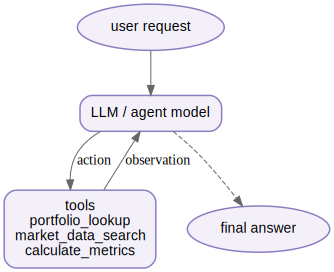

In [ ]:
from graphviz import Digraph
from IPython.display import display

def draw_financial_react_diagram():
    dot = Digraph("financial_react", format="png")
    dot.attr(rankdir="TB", splines="spline", nodesep="0.45", ranksep="0.6")
    dot.attr(bgcolor="white")

    edge_color = "#666666"
    node_outline = "#8E7CC3"
    node_fill = "#F3F0FA"

    dot.attr(
        "node",
        style="rounded,filled",
        color=node_outline,
        fillcolor=node_fill,
        fontname="Helvetica",
        fontsize="14",
        penwidth="1.5",
        margin="0.20,0.13",
    )

    dot.node("request", "user request", shape="oval")
    dot.node("model", "LLM / agent model", shape="box")
    dot.node("tools", "tools\nportfolio_lookup\nmarket_data_search\ncalculate_metrics", shape="box")
    dot.node("result", "final answer", shape="oval")

    with dot.subgraph() as s:
        s.attr(rank="same")
        s.node("tools")
        s.node("result")

    dot.edge("request", "model", color=edge_color)
    dot.edge("model", "tools", label="action", color=edge_color)
    dot.edge("tools", "model", label="observation", color=edge_color)
    dot.edge("model", "result", style="dashed", color=edge_color)

    return dot

display(draw_financial_react_diagram())

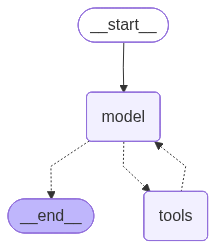

In [ ]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 11. Run Agent — Quarterly Client Briefing

The main use case: preparing a comprehensive briefing for a quarterly client meeting. Watch how the agent autonomously queries the database, searches policy PDFs, and pulls live web data.

In [ ]:
query1 = """Prepare a quarterly briefing for Client CLT-001 (Rajesh Mehta).
Include: portfolio performance summary with per-holding returns, relevant market conditions
for his sectors, check if his current allocation complies with our investment policies for
his risk profile (Moderate-Aggressive), and provide any recommended rebalancing actions.
Also check for latest news on sectors he is most exposed to."""

print(f"📋 Query: {query1}")
print(f"{'='*80}\n")

# result1 = agent.invoke({"messages": [("user", query1)]})
result1 = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": query1}
        ]
    }
)

print("\n🤖 AGENT RESPONSE:")
print(f"{'─'*80}")
# print(result1["messages"][-1].content)
final_msg = result1["messages"][-1]
print(final_msg.content if hasattr(final_msg, "content") else final_msg)

📋 Query: Prepare a quarterly briefing for Client CLT-001 (Rajesh Mehta).
Include: portfolio performance summary with per-holding returns, relevant market conditions
for his sectors, check if his current allocation complies with our investment policies for
his risk profile (Moderate-Aggressive), and provide any recommended rebalancing actions.
Also check for latest news on sectors he is most exposed to.


🤖 AGENT RESPONSE:
────────────────────────────────────────────────────────────────────────────────
Quarterly Briefing — Rajesh Mehta (CLT-001)
Date: 2026-04-05
Relationship Manager: Anita Desai
Risk profile: Moderate‑Aggressive (confirmed)

Portfolio Summary
- Total market value: ₹2,532,500 (₹25.33 lakh)
- Cost basis: ₹1,894,000
- YTD / Quarter performance: overall unrealized gain ₹638,500 (33.7% since cost basis)
- Per‑holding detail (current price, market value, cost gain, portfolio weight, YTD):
  1. TCS (TCS) — 150 shares @ ₹4,250 → value ₹637,500; unrealized gain ₹127,500 (+25.0%)

## 12. Agent Trace — Tool Calls & Reasoning

Let's inspect the full trace to understand the agent's decision-making: which tools it called, in what order, and what it observed.

In [ ]:
print("🔍 AGENT TRACE — Full Message History")
print(f"{'='*80}\n")

for i, msg in enumerate(result1["messages"]):
    msg_type = type(msg).__name__

    if msg_type == "HumanMessage":
        print(f"Step {i} | 👤 USER:")
        print(f"   {msg.content[:200]}...")

    elif msg_type == "AIMessage":
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            print(f"\nStep {i} | 🧠 AGENT → calls {len(msg.tool_calls)} tool(s):")
            for tc in msg.tool_calls:
                args_str = json.dumps(tc['args'], ensure_ascii=False)[:120]
                print(f"   🔧 {tc['name']}({args_str})")
        else:
            print(f"\nStep {i} | 🤖 FINAL ANSWER ({len(msg.content)} chars)")

    elif msg_type == "ToolMessage":
        print(f"\nStep {i} | 📦 TOOL: {msg.name}")
        print(f"   {str(msg.content)[:200]}...")

print(f"\n{'='*80}")
tool_msgs = [m for m in result1["messages"] if type(m).__name__ == "ToolMessage"]
print(f"Total steps: {len(result1['messages'])} | Tool calls: {len(tool_msgs)}")
print(f"Tools used: {[m.name for m in tool_msgs]}")

🔍 AGENT TRACE — Full Message History

Step 0 | 👤 USER:
   Prepare a quarterly briefing for Client CLT-001 (Rajesh Mehta).
Include: portfolio performance summary with per-holding returns, relevant market conditions
for his sectors, check if his current alloca...

Step 1 | 🧠 AGENT → calls 1 tool(s):
   🔧 portfolio_lookup({"client_id": "CLT-001"})

Step 2 | 📦 TOOL: portfolio_lookup
   {
  "client_id": "CLT-001",
  "name": "Rajesh Mehta",
  "relationship_manager": "Anita Desai",
  "risk_profile": "Moderate-Aggressive",
  "investment_horizon": "7-10yr",
  "aum_inr": 12500000.0,
  "la...

Step 3 | 🧠 AGENT → calls 1 tool(s):
   🔧 policy_retriever({"query": "Moderate-Aggressive client asset allocation limits sector concentration single-stock limit rebalancing trigge)

Step 4 | 📦 TOOL: policy_retriever
   [Policy Doc 1: Risk_Management_Guidelines.pdf | Page 18]
fixed-income 20-35%, alternatives 0-5%), and Aggressive (equities 80-90%, fixed-income 5-15%,
alternatives 0-5%). These limits reflect 

## 13. Run Agent — Cross-Client Comparison with Policy Check

This query requires the agent to query the database for two clients, compare positions, and search policy PDFs for concentration rules.

In [ ]:
def call_agent(query):
  print(f"📋 Query: {query2}")
  print(f"{'='*80}\n")

  result = agent.invoke(
      {
          "messages": [
              {"role": "user", "content": query}
          ]
      }
  )

  print("\n🤖 AGENT RESPONSE:")
  print(f"{'─'*80}")

  final_msg = result["messages"][-1]
  print(final_msg.content if hasattr(final_msg, "content") else final_msg)

  tool_calls = [m for m in result["messages"] if type(m).__name__ == "ToolMessage"]
  print(f"\n📊 Tools used: {[m.name for m in tool_calls]}")

  web_calls = [m for m in result["messages"] if type(m).__name__ == "ToolMessage" and m.name == "tavily_search"]
  print(f"\n🌐 Web search called: {len(web_calls)} time(s)")

  # Verify policy_retriever was used
  policy_calls = [m for m in result["messages"] if type(m).__name__ == "ToolMessage" and m.name == "policy_retriever"]
  print(f"\n📚 Policy retriever called: {len(policy_calls)} time(s)")
  for pc in policy_calls:
      pdf_refs = re.findall(r'[A-Za-z_]+\.pdf', pc.content)
      if pdf_refs:
          print(f"   Referenced PDFs: {', '.join(set(pdf_refs))}")

  return result

In [ ]:
query2 = """Compare the IT sector exposure of Client CLT-001 and Client CLT-002.
Which client is more overweight in IT? Check our sector concentration policy limits
from the policy documents and recommend if either client needs to trim IT positions.
Also look up the latest market outlook for Indian IT sector."""

result2 = call_agent(query2)

📋 Query: Compare the IT sector exposure of Client CLT-001 and Client CLT-002.
Which client is more overweight in IT? Check our sector concentration policy limits
from the policy documents and recommend if either client needs to trim IT positions.
Also look up the latest market outlook for Indian IT sector.


🤖 AGENT RESPONSE:
────────────────────────────────────────────────────────────────────────────────
Portfolio Summary
- CLT-001 (Rajesh Mehta) — Risk profile: Moderate‑Aggressive. Total portfolio value: ₹2,532,500.
  - IT allocation: 44.1% (TCS ₹637,500 = 25.2%; Infosys ₹480,000 = 19.0%). Total IT value = ₹1,117,500.
- CLT-002 (Priya Kapoor) — Risk profile: Conservative. Total portfolio value: ₹3,145,000.
  - IT allocation: 13.5% (TCS only: ₹425,000 = 13.5%).

Market Context — Indian IT sector (latest)
- Structural reset driven by AI adoption: broker/analyst commentary points to lower near‑term revenue growth and pricing pressure in traditional services, with productivity gains visi

## 14. Run Agent — Single-Stock Concentration & Risk Policy Check

This query specifically tests the RAG policy retriever — the agent must search PDF documents for concentration limits and stop-loss rules.

In [ ]:
query3 = """Client CLT-003 (Amit Choudhury) wants to increase his position in Adani Enterprises.
Check his current Adani holding as a percentage of his total portfolio from the database,
then search our policy documents for the single-stock concentration limit and the stop-loss
framework for his risk profile (Aggressive). Advise whether this purchase is permissible."""

result3 = call_agent(query3)

📋 Query: Compare the IT sector exposure of Client CLT-001 and Client CLT-002.
Which client is more overweight in IT? Check our sector concentration policy limits
from the policy documents and recommend if either client needs to trim IT positions.
Also look up the latest market outlook for Indian IT sector.


🤖 AGENT RESPONSE:
────────────────────────────────────────────────────────────────────────────────
Portfolio Summary
- Client: Amit Choudhury (CLT-003) — Risk profile: Aggressive.
- Total portfolio market value: ₹3,700,500 (≈ ₹37.00 lakh).
- Current Adani Enterprises (ADANIENT) holding: market value ₹690,000 (200 shares @ ₹3,450).
- ADANIENT weight in portfolio: 18.65% (₹690,000 / ₹3,700,500).

Market Context
- ADANIENT is already a large concentrated equity position for this client (current weight 18.65%). No further market-data analysis is required to assess policy permissibility — the decision rests on policy limits for single-stock concentration and stop-loss rules given an Agg

## 15. Run Agent — Live Web Search for Market Intelligence

This query tests Tavily web search — the agent searches for real-time market information not available in our internal data.

In [ ]:
query4 = """Client CLT-005 (Karan Malhotra) has heavy exposure to Telecom and Auto sectors.
Look up his portfolio from the database, then search the web for the latest news on RBI
monetary policy decisions and their potential impact on these sectors.
Summarize the outlook and recommend any portfolio actions."""

result4 = call_agent(query4)

📋 Query: Compare the IT sector exposure of Client CLT-001 and Client CLT-002.
Which client is more overweight in IT? Check our sector concentration policy limits
from the policy documents and recommend if either client needs to trim IT positions.
Also look up the latest market outlook for Indian IT sector.


🤖 AGENT RESPONSE:
────────────────────────────────────────────────────────────────────────────────
Portfolio Summary
- Client: Karan Malhotra (CLT-005) — Risk profile: Aggressive; Investment horizon: 10+ years.
- Total portfolio value: ₹3,704,000 (₹37.04 lakh).
- Key sector exposures (current):
  - Auto (TATA MOTORS): ₹840,000 (22.7% of portfolio)
  - Telecom (BHARTI AIRTEL): ₹700,000 (18.9% of portfolio)
  - Combined Auto + Telecom = ₹1,540,000 = 41.58% of portfolio (calculated: ₹1,540,000 / ₹3,704,000 = 41.58%).
    - Source: portfolio database / metric calculation result.
- Other large holdings: ADANIENT ₹1,035,000 (27.9% weight), RELIANCE ₹745,000 (20.1%), INFY ₹384,000 (10.4%)

## 16. Agent Performance Summary

In [ ]:
all_results = [
    ("Client Briefing (CLT-001)", result1),
    ("IT Sector Comparison", result2),
    ("Concentration Policy Check", result3),
    ("Web Search + Sector Outlook", result4)
]

print("📊 Agent Tool Usage Summary")
print(f"{'='*70}")
print(f"{'Query':<35} {'# Tools':<10} {'Tools Used'}")
print(f"{'─'*70}")

total_calls = 0
tool_freq = {}

for name, result in all_results:
    tmsgs = [m for m in result["messages"] if type(m).__name__ == "ToolMessage"]
    tnames = [m.name for m in tmsgs]
    total_calls += len(tnames)
    for tn in tnames:
        tool_freq[tn] = tool_freq.get(tn, 0) + 1
    print(f"{name:<35} {len(tnames):<10} {', '.join(tnames)}")

print(f"{'─'*70}")
print(f"{'TOTAL':<35} {total_calls}")

print(f"\n📈 Tool Frequency:")
for tn, cnt in sorted(tool_freq.items(), key=lambda x: -x[1]):
    print(f"   {tn:<25} {cnt:>2} {'█' * cnt}")

# Data infrastructure summary
conn = sqlite3.connect(DB_PATH)
print(f"\n🏗️ Data Infrastructure Summary:")
print(f"   SQLite: {DB_PATH} ({os.path.getsize(DB_PATH)/1024:.0f} KB)")
for table in ["clients", "holdings", "market_data"]:
    cnt = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"     → {table}: {cnt} rows")
conn.close()
print(f"   FAISS: {policy_vectorstore.index.ntotal} vectors from {len(pdf_files)} policy PDFs")
print(f"   Web: Tavily API (live search)")

📊 Agent Tool Usage Summary
Query                               # Tools    Tools Used
──────────────────────────────────────────────────────────────────────
Client Briefing (CLT-001)           12         portfolio_lookup, policy_retriever, tavily_search, tavily_search, market_data_search, market_data_search, policy_retriever, policy_retriever, calculate_metrics, policy_retriever, policy_retriever, policy_retriever
IT Sector Comparison                13         portfolio_lookup, portfolio_lookup, policy_retriever, policy_retriever, policy_retriever, policy_retriever, policy_retriever, market_data_search, tavily_search, tavily_search, tavily_search, tavily_search, tavily_search
Concentration Policy Check          4          portfolio_lookup, policy_retriever, policy_retriever, calculate_metrics
Web Search + Sector Outlook         9          portfolio_lookup, tavily_search, policy_retriever, policy_retriever, policy_retriever, policy_retriever, tavily_search, policy_retriever, policy_retri

## 17. Conclusion & Next Steps

### What We Built — Portfolio Project Deliverable 🏗️

A **production-grade ReAct agent** for wealth management that:
- Queries a **SQLite database** with 3 normalized tables (clients, holdings, market data)
- Loads **5 real PDF policy documents** through a full RAG pipeline (PyPDFLoader → RecursiveCharacterTextSplitter → OpenAI embeddings → FAISS)
- Searches the **live web** via Tavily API for real-time market intelligence
- Autonomously orchestrates **5 tools** to prepare comprehensive client briefings

### Production Architecture Mapping
| Component | This Lab | Production Equivalent |
|-----------|---------|----------------------|
| Structured data | SQLite | PostgreSQL / Snowflake / Oracle |
| Document store | PDF files on disk | S3 / SharePoint / Document Management System |
| Vector store | FAISS (in-memory) | Pinecone / Weaviate / pgvector |
| Embeddings | text-embedding-3-small | Same, or domain-fine-tuned model |
| Agent LLM | gpt-5-mini | Same, with guardrails and rate limits |
| Web search | Tavily API | Same, or Bloomberg/Reuters enterprise feeds |

### Key Takeaways
1. **Real databases > Python dicts** — SQL gives you joins, filtering, aggregation, and scales to millions of rows
2. **PDF → RAG pipeline** is the production pattern: Load → Split → Embed → Store → Retrieve
3. **Chunk size matters** — 500 chars with 100 overlap balances precision vs. context
4. **RAG as a tool** — the agent decides *when* to search policies, not the developer
5. **The ReAct trace is your debugging superpower** — always inspect tool call sequences in development

### Extension Exercises
- Add a `generate_pdf_report` tool that creates a formatted QPR from the agent's findings
- Implement **conversation memory** with `MemorySaver` for multi-turn client discussions
- Add **human-in-the-loop** approval before executing rebalancing recommendations
- Connect to a real market data API (Yahoo Finance or NSE Bhavcopy) instead of static data
- Deploy as a **FastAPI service** with authentication and rate limiting

### What's Next
**Lab 5 (Module 2):** We move from single-agent to **multi-step workflows** with LangGraph. First pattern: **Routing** — building a customer support system that classifies queries and routes them to specialized handlers. This is **Spine A** (E-Commerce Customer Support)! 🚀

In [1]:
# 1. Zip the policy_documents folder and the meridian_wealth.db file
# !zip -r backup.zip policy_documents/ meridian_wealth.db

# 2. Unzip the file (uncomment the line below to run it)
# !unzip backup.zip -d unzipped_backup/

In [ ]:
# !rm -rf policy_documents

In [ ]:
# !unzip policy_documents.zip -d .

Archive:  policy_documents.zip
   creating: ./policy_documents/
  inflating: ./policy_documents/Risk_Management_Guidelines.pdf  
  inflating: ./policy_documents/Rebalancing_Protocol.pdf  
  inflating: ./policy_documents/Client_Suitability_Standards.pdf  
  inflating: ./policy_documents/Asset_Allocation_Policy.pdf  
  inflating: ./policy_documents/Quarterly_Reporting_Standards.pdf  
  inflating: ./meridian_wealth.db    


---
## 9. Conclusion & Key Takeaways

### What We Covered

| Concept | Takeaway |
|---|---|
| **`from langchain.agents import create_agent`** | LangChain v1 path — replaces legacy `AgentExecutor`. Returns a Runnable that streams, batches, and composes. |
| **4-tool ReAct loop** | SQL · Vector RAG · Live web · Calculator. The model picks the right tool per question; that's what makes it agentic. |
| **SQL via natural language** | `langchain_community.utilities.SQLDatabase` + a tool wrapper — the agent can run any SELECT against the schema you expose. |
| **Vector RAG over PDFs** | PyPDF + RecursiveCharacterTextSplitter + FAISS + OpenAIEmbeddings — wrap the retriever in a `@tool` for the agent. |
| **Live web search** | Tavily as a `@tool` — the agent calls it only when it needs *current* information the static knowledge base can't provide. |
| **Debugging the loop** | Stream `astream_events` and watch `on_tool_start` / `on_tool_end` — tool selection bugs and infinite loops both show up here first. |
| **Production handoff** | When the use case needs strict step ordering, HITL approvals, or multi-agent supervision → graduate from `create_agent` to `StateGraph` (Module 8). |

**Next Lab:** Module 8 — Multi-Agent Systems · Supervisor, Orchestrator-Worker, MAF (autogen-agentchat) 🤝


## 10. Stretch Exercise (Optional)

1. Add a **portfolio-rebalancing simulator** as a 5th tool — given a target asset allocation, the tool returns the trades needed to rebalance.
2. Wire **conversation memory** so the agent remembers earlier turns in a client-meeting prep session. (Hint: `RunnableWithMessageHistory` wrapping `create_agent`'s output.)
3. Replace the in-memory FAISS index with a **persistent vector store** (Chroma DuckDB, Qdrant, or pgvector) so policy documents survive a notebook restart.
4. Add a **tool-usage analytics callback** that logs every `on_tool_start` event to a CSV — which tools get called for which kinds of questions.
5. Convert the agent to a **two-tier supervisor pattern** (Module 8 preview): a research sub-agent (RAG + web) and a numbers sub-agent (SQL + calculator), with a top-level supervisor.
6. Benchmark the agent on 10 realistic client-meeting prep questions and measure: tokens-per-question, tool-call accuracy, hallucination rate (LLM-as-Judge).
